*Instalação*

In [ ]:
!pip install shap

Importação e Preparação dos Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import shap

warnings.filterwarnings('ignore')

# Carregamento do dataset
dataset_path = 'mental_health_burnout_prediction_dataset.csv'
try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    print("Por favor, faça o upload do arquivo 'mental_health_burnout_prediction_dataset.csv' no Colab.")

if 'df' in locals():
    # Remover colunas desnecessárias
    df = df.drop(columns=['Person_ID', 'AI_Wellness_Recommendation'])

    # Binarizar o Target (High/Critical -> 1, Low/Moderate -> 0)
    df['Burnout_Risk_Binary'] = df['Burnout_Risk'].apply(lambda x: 1 if x in ['High', 'Critical'] else 0)

    X = df.drop(columns=['Burnout_Risk', 'Burnout_Score', 'Burnout_Risk_Binary'])
    y = df['Burnout_Risk_Binary']

    # Identificar colunas numéricas e categóricas
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns

    # Tratar valores nulos (estritamente pandas)
    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())
    for col in cat_cols:
        X[col] = X[col].fillna(X[col].mode()[0])

    # Converter categóricas (One-Hot Encoding)
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # Divisão Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Dados preparados com sucesso!")

Dados preparados com sucesso!


Normalização e Treinamento

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

if 'df' in locals():
    # Normalizando os dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Criando e Treinando o Modelo com Keras (64 e 32 neurônios)
    modelo_mlp = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Sigmoid para saída binária (0 ou 1)
    ])

    modelo_mlp.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("Treinando o modelo Keras...")
    historico = modelo_mlp.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

Treinando o modelo Keras...
Epoch 1/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9463 - loss: 0.1374 - val_accuracy: 0.9808 - val_loss: 0.0726
Epoch 2/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0535 - val_accuracy: 0.9814 - val_loss: 0.0668
Epoch 3/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9868 - loss: 0.0431 - val_accuracy: 0.9808 - val_loss: 0.0634
Epoch 4/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9761 - val_loss: 0.0673
Epoch 5/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9896 - loss: 0.0310 - val_accuracy: 0.9828 - val_loss: 0.0675
Epoch 6/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9768 - val_loss: 0.0687
Epoch 7/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0180 - val_accuracy: 0.9775 - val_loss: 0.0749
Epoch 8/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9952 - lo

Conectar Drive e Salvar

In [ ]:
from google.colab import drive

# 1. Monta o Drive (vai pedir autorização do Google)
drive.mount('/content/drive')

if 'modelo_mlp' in locals():
    # 2. Salva o modelo na raiz do seu Drive com as aspas corretas!
    caminho_salvar = '/content/drive/MyDrive/model.keras'
    modelo_mlp.save(caminho_salvar)
    print(f"Modelo salvo com sucesso no Drive como '{caminho_salvar}'")

Mounted at /content/drive
Modelo salvo com sucesso no Drive como '/content/drive/MyDrive/model.keras'


Resultados - Curvas de Loss e Acurácia

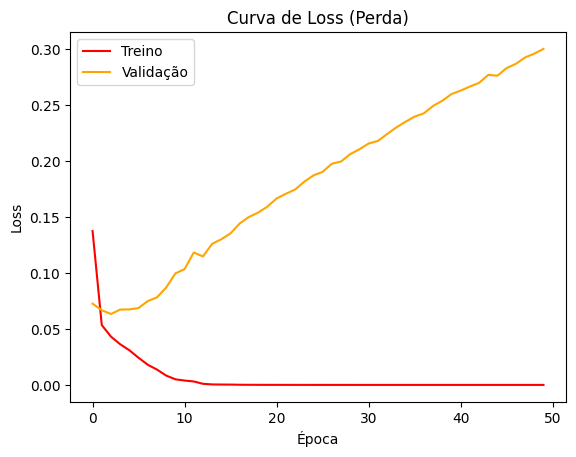

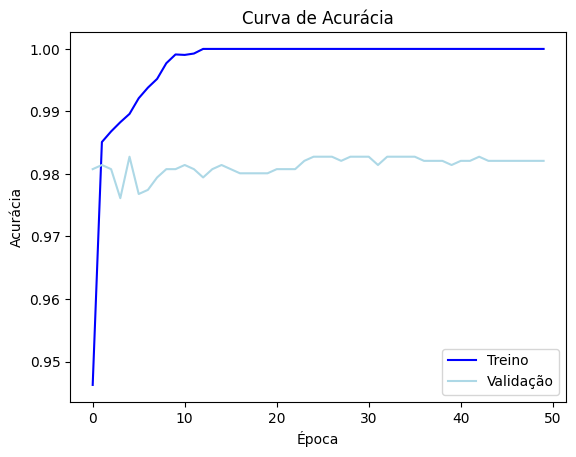

In [ ]:
if 'historico' in locals():
    # Plot da Curva de Loss
    plt.figure()
    plt.plot(historico.history['loss'], color='red', label='Treino')
    plt.plot(historico.history['val_loss'], color='orange', label='Validação')
    plt.title("Curva de Loss (Perda)")
    plt.ylabel("Loss")
    plt.xlabel("Época")
    plt.legend()
    plt.show()

    # Plot da Curva de Acurácia
    plt.figure()
    plt.plot(historico.history['accuracy'], color='blue', label='Treino')
    plt.plot(historico.history['val_accuracy'], color='lightblue', label='Validação')
    plt.title("Curva de Acurácia")
    plt.ylabel("Acurácia")
    plt.xlabel("Época")
    plt.legend()
    plt.show()

Avaliação do Modelo e Matriz de Confusão

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Resultados da Avaliação:
Acurácia: 0.9835456475583864
Precisão: 0.9839750325658114
Sensibilidade: 0.9835456475583864
F1-Score: 0.9836667725404711


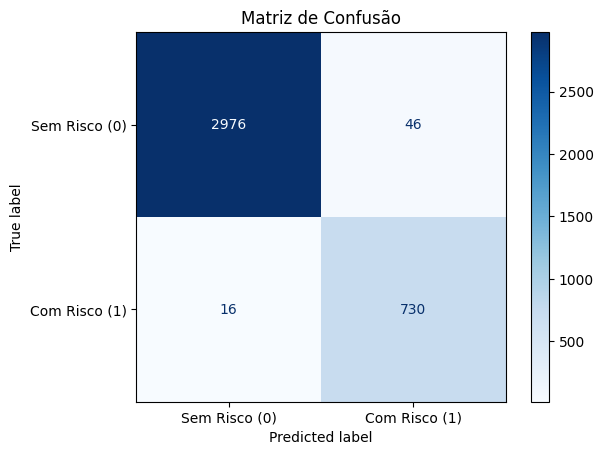

In [ ]:
if 'df' in locals():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

    # O Keras retorna a probabilidade. Aqui convertemos probabilidade > 0.5 para classe 1, senão 0.
    previsoes_prob = modelo_mlp.predict(X_test_scaled)
    output_model_ = (previsoes_prob > 0.5).astype(int).flatten()

    print('\nResultados da Avaliação:')
    print('Acurácia:', accuracy_score(y_test, output_model_))
    print('Precisão:', precision_score(y_test, output_model_, average='weighted'))
    print('Sensibilidade:', recall_score(y_test, output_model_, average='weighted'))
    print('F1-Score:', f1_score(y_test, output_model_, average='weighted'))

    cm = confusion_matrix(y_test, output_model_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Risco (0)', 'Com Risco (1)'])
    disp.plot(cmap=plt.cm.Blues)
    disp.ax_.set_title('Matriz de Confusão')
    plt.show()

Gráficos SHAP

  0%|          | 0/3768 [00:00<?, ?it/s]

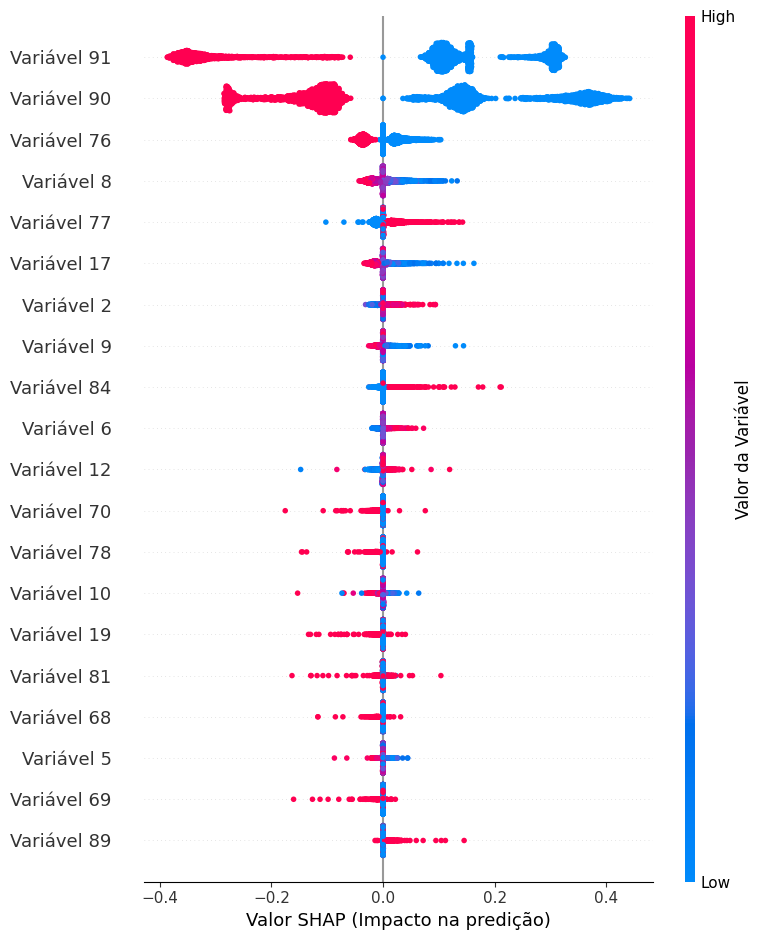

In [ ]:
if 'df' in locals():
    # Função para ajudar o SHAP a ler as predições do Keras
    def pred_wrapper(x):
        return modelo_mlp.predict(x, verbose=0).flatten()

    # K-means para otimizar a velocidade do SHAP
    X_train_summary = shap.kmeans(X_train_scaled, 10)
    explainer = shap.KernelExplainer(pred_wrapper, X_train_summary)

    # Calculando os valores SHAP
    shap_values = explainer.shap_values(X_test_scaled)

    # 1. Trocando "Feature X" para "Variável X" (Eixo Y)
    nomes_variaveis = [f"Variável {i}" for i in range(X_test_scaled.shape[1])]

    shap.summary_plot(shap_values, X_test_scaled, feature_names=nomes_variaveis, show=False)

    # 2. Traduzindo a barra lateral (Feature Value) e o eixo X
    fig = plt.gcf()
    if len(fig.axes) > 1:
        cax = fig.axes[-1]  # Pega a barra de cores lateral
        cax.set_ylabel('Valor da Variável', fontsize=12)

    plt.xlabel("Valor SHAP (Impacto na predição)")
    plt.show()